# Section 2: Exploratory Data Analysis & Tree Models

**Student ID:** IT24102778  
**Technical Role:** EDA & Tree Models  
**Module:** IT3091 Machine Learning | **Group:** 2026-DS-58  
**Dataset:** Ames Housing | **Target:** SalePrice | **Seed:** 42  

---

## Section Scope

This notebook loads the fixed 80/20 train/test split established in Notebook 01 and:

1. Conducts exploratory data analysis (EDA) to justify preprocessing choices (duplicate checks, missingness patterns, `GrLivArea` outlier identification, skewness, and feature correlations).
2. Applies outlier removal **strictly to the training fold** to preserve test-set integrity.
3. Trains and evaluates Decision Tree and Random Forest regressors as the tree-based model baseline.
4. Exports the removed-outlier index list and initial feature matrices so downstream pipeline steps build on the exact same cleaned training split.

In [1]:
# Imports & Global Configuration
import os
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Environment and results directory initialized.")

Environment and results directory initialized.


In [2]:
# Locate dataset & reproduce the SAME fixed split Role A created (seed=42)
def find_file(filename):
    search_paths = [
        Path(filename),
        Path(f"results/{filename}"),
        Path(f"/kaggle/input/{filename}"),
    ]
    for p in search_paths:
        if p.exists():
            return p
    if Path("/kaggle/input").exists():
        found = list(Path("/kaggle/input").rglob(filename))
        if found:
            return found[0]
    return None

train_csv_path = find_file("train.csv")
if train_csv_path is None:
    raise FileNotFoundError("Could not find train.csv. Make sure the competition dataset is attached.")

df_raw = pd.read_csv(train_csv_path)
df_clean = df_raw.drop(columns=["Id"]) if "Id" in df_raw.columns else df_raw.copy()
X = df_clean.drop(columns=["SalePrice"])
y = df_clean["SalePrice"]

train_idx_path = find_file("train_indices.csv")
test_idx_path = find_file("test_indices.csv")
split_joblib_path = find_file("split_indices.joblib")

if train_idx_path and test_idx_path:
    train_idx = pd.read_csv(train_idx_path).values.flatten()
    test_idx = pd.read_csv(test_idx_path).values.flatten()
    print("Loaded split indices from CSV files (from Role A / Notebook 01).")
elif split_joblib_path:
    split_data = joblib.load(split_joblib_path)
    train_idx = split_data["train_idx"]
    test_idx = split_data["test_idx"]
    print("Loaded split indices from joblib file.")
else:
    print("Split files not found in workspace. Generating reproducible split (seed=42) as a fallback...")
    train_idx, test_idx = train_test_split(np.arange(len(X)), test_size=0.2, random_state=RANDOM_SEED)
    pd.DataFrame({"train_idx": train_idx}).to_csv(RESULTS_DIR / "train_indices.csv", index=False)
    pd.DataFrame({"test_idx": test_idx}).to_csv(RESULTS_DIR / "test_indices.csv", index=False)

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Loaded split indices from CSV files (from Role A / Notebook 01).
Train shape: (1168, 79) | Test shape: (292, 79)


## 2.1 Exploratory Data Analysis

The EDA insight log for this dataset evaluates five core areas required by the project plan:
1. Duplicate row checks.
2. Structural meaning of missing values (distinguishing structural NAs from true missingness).
3. Identification of the known Ames `GrLivArea` outliers.
4. Skewness of the target variable (`SalePrice`) and key numeric features.
5. Linear correlations between numeric predictors and the target variable.

All exploratory findings and data treatment decisions are derived **strictly from the training fold** - the test set remains completely untouched until final model evaluation, preserving the group's shared leakage-safe modelling rules.

In [3]:
# --- Duplicate rows ---
train_full = X_train.copy()
train_full["SalePrice"] = y_train

n_dupes = train_full.duplicated().sum()
print(f"Exact duplicate rows in training data: {n_dupes}")

if n_dupes > 0:
    train_full = train_full.drop_duplicates()
    print(f"Dropped {n_dupes} duplicate row(s). New training shape: {train_full.shape}")
else:
    print("No exact duplicate rows found.")

Exact duplicate rows in training data: 0
No exact duplicate rows found.


In [4]:
# --- Missingness meaning ---
# Ames' data dictionary defines NA as a real category ("does not have this feature")
# for a known set of columns. Treating these as random gaps and median/mode-imputing
# them blindly would erase real information (e.g. "no pool" vs "pool quality unknown").
CANDIDATE_NA_MEANINGFUL = [
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]
NA_MEANING = {
    "PoolQC": "No pool on the property",
    "MiscFeature": "No additional misc feature (shed, tennis court, etc.)",
    "Alley": "No alley access",
    "Fence": "No fence",
    "FireplaceQu": "No fireplace",
    "GarageType": "No garage", "GarageFinish": "No garage",
    "GarageQual": "No garage", "GarageCond": "No garage",
    "BsmtQual": "No basement", "BsmtCond": "No basement", "BsmtExposure": "No basement",
    "BsmtFinType1": "No basement", "BsmtFinType2": "No basement",
    "MasVnrType": "No masonry veneer",
}

missing_rows = []
for col in CANDIDATE_NA_MEANINGFUL:
    if col in train_full.columns:
        pct = train_full[col].isnull().mean() * 100
        if pct > 0:
            missing_rows.append({"Feature": col, "Missing_Pct": round(pct, 2), "Likely_Meaning": NA_MEANING[col]})

missingness_meaning_df = (
    pd.DataFrame(missing_rows).sort_values("Missing_Pct", ascending=False)
    if missing_rows else pd.DataFrame(columns=["Feature", "Missing_Pct", "Likely_Meaning"])
)

# Anything ELSE missing is a genuine gap (data entry issue) rather than a "not applicable" category
other_missing = (
    train_full.drop(columns=[c for c in CANDIDATE_NA_MEANINGFUL if c in train_full.columns])
    .isnull().mean() * 100
)
other_missing = other_missing[other_missing > 0].sort_values(ascending=False)

print("Structural 'NA = category absent' features (should be encoded as their own category, NOT dropped/median-filled):")
display(missingness_meaning_df)

print("\nOther missing values (likely genuine gaps needing numeric/mode imputation):")
display(other_missing)

missingness_meaning_df.to_csv(RESULTS_DIR / "02_missingness_meaning.csv", index=False)
other_missing.reset_index().rename(columns={"index": "Feature", 0: "Missing_Pct"}).to_csv(
    RESULTS_DIR / "02_missingness_other.csv", index=False
)

Structural 'NA = category absent' features (should be encoded as their own category, NOT dropped/median-filled):


,Feature,Missing_Pct,Likely_Meaning
0,PoolQC,99.49,No pool on the property
1,MiscFeature,96.06,"No additional misc feature (shed, tennis court..."
2,Alley,93.66,No alley access
3,Fence,80.05,No fence
14,MasVnrType,58.48,No masonry veneer
4,FireplaceQu,46.83,No fireplace
5,GarageType,5.48,No garage
6,GarageFinish,5.48,No garage
7,GarageQual,5.48,No garage
8,GarageCond,5.48,No garage



Other missing values (likely genuine gaps needing numeric/mode imputation):


LotFrontage    18.578767
GarageYrBlt     5.479452
MasVnrArea      0.513699
Electrical      0.085616
dtype: float64

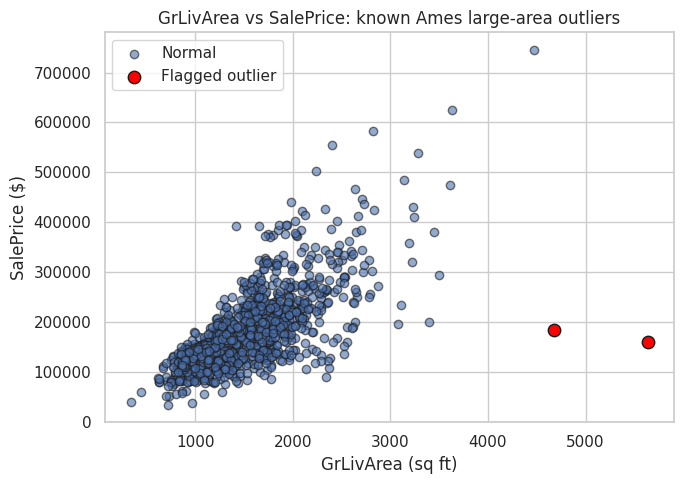

Flagged 2 training row(s) as GrLivArea/SalePrice outliers (area > 4000 sqft, price < $300k).
Training shape after outlier removal: (1166, 80)
Decision: removed from TRAINING data only. Test set is never touched by an EDA/cleaning decision.


In [5]:
# --- Known Ames outliers: very large GrLivArea sold at a disproportionately low price ---
# These two records are a well-documented data quirk in the Ames dataset (the seller's
# own documentation flags them as unusual/partial sales). Left in, they distort both
# linear and tree-based fits by pulling the regression toward atypical, high-leverage points.
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(train_full["GrLivArea"], train_full["SalePrice"], alpha=0.6, edgecolor="k", label="Normal")

outlier_mask = (train_full["GrLivArea"] > 4000) & (train_full["SalePrice"] < 300000)
ax.scatter(
    train_full.loc[outlier_mask, "GrLivArea"], train_full.loc[outlier_mask, "SalePrice"],
    color="red", edgecolor="k", s=80, label="Flagged outlier",
)
ax.set_xlabel("GrLivArea (sq ft)")
ax.set_ylabel("SalePrice ($)")
ax.set_title("GrLivArea vs SalePrice: known Ames large-area outliers")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_grlivarea_outliers.png", dpi=150)
plt.show()

n_outliers = int(outlier_mask.sum())
print(f"Flagged {n_outliers} training row(s) as GrLivArea/SalePrice outliers (area > 4000 sqft, price < $300k).")

removed_idx = train_full.loc[outlier_mask].index.tolist()
train_full_clean = train_full.loc[~outlier_mask].copy()
print(f"Training shape after outlier removal: {train_full_clean.shape}")
print("Decision: removed from TRAINING data only. Test set is never touched by an EDA/cleaning decision.")

In [6]:
# --- Skewness of target and numeric features ---
numeric_cols = train_full_clean.select_dtypes(include=[np.number]).columns.tolist()
skew_series = train_full_clean[numeric_cols].apply(lambda s: skew(s.dropna())).sort_values(ascending=False)
skew_df = skew_series.reset_index()
skew_df.columns = ["Feature", "Skewness"]

print("Top 10 most right-skewed numeric features:")
display(skew_df.head(10))

target_skew_before = skew(train_full_clean["SalePrice"])
target_skew_after = skew(np.log1p(train_full_clean["SalePrice"]))
print(f"\nSalePrice skewness: raw = {target_skew_before:.3f} | log1p-transformed = {target_skew_after:.3f}")
print(
    "Decision (logged for the group): SalePrice's raw skew is mild here, so this notebook keeps the "
    "target untransformed for tree models (they are not sensitive to monotonic transforms of the "
    "target the way Linear Regression is). If Role A's Linear Regression residuals look "
    "heteroscedastic, a log1p target transform is the group's agreed fallback -- log it in the "
    "shared decision log either way."
)
skew_df.to_csv(RESULTS_DIR / "02_skewness.csv", index=False)

Top 10 most right-skewed numeric features:


,Feature,Skewness
0,MiscVal,22.006393
1,PoolArea,15.673692
2,LotArea,12.333963
3,3SsnPorch,9.812616
4,LowQualFinSF,9.179493
5,KitchenAbvGr,4.434981
6,BsmtFinSF2,4.208323
7,ScreenPorch,4.081056
8,BsmtHalfBath,3.996596
9,EnclosedPorch,3.156446



SalePrice skewness: raw = 1.739 | log1p-transformed = 0.125
Decision (logged for the group): SalePrice's raw skew is mild here, so this notebook keeps the target untransformed for tree models (they are not sensitive to monotonic transforms of the target the way Linear Regression is). If Role A's Linear Regression residuals look heteroscedastic, a log1p target transform is the group's agreed fallback -- log it in the shared decision log either way.


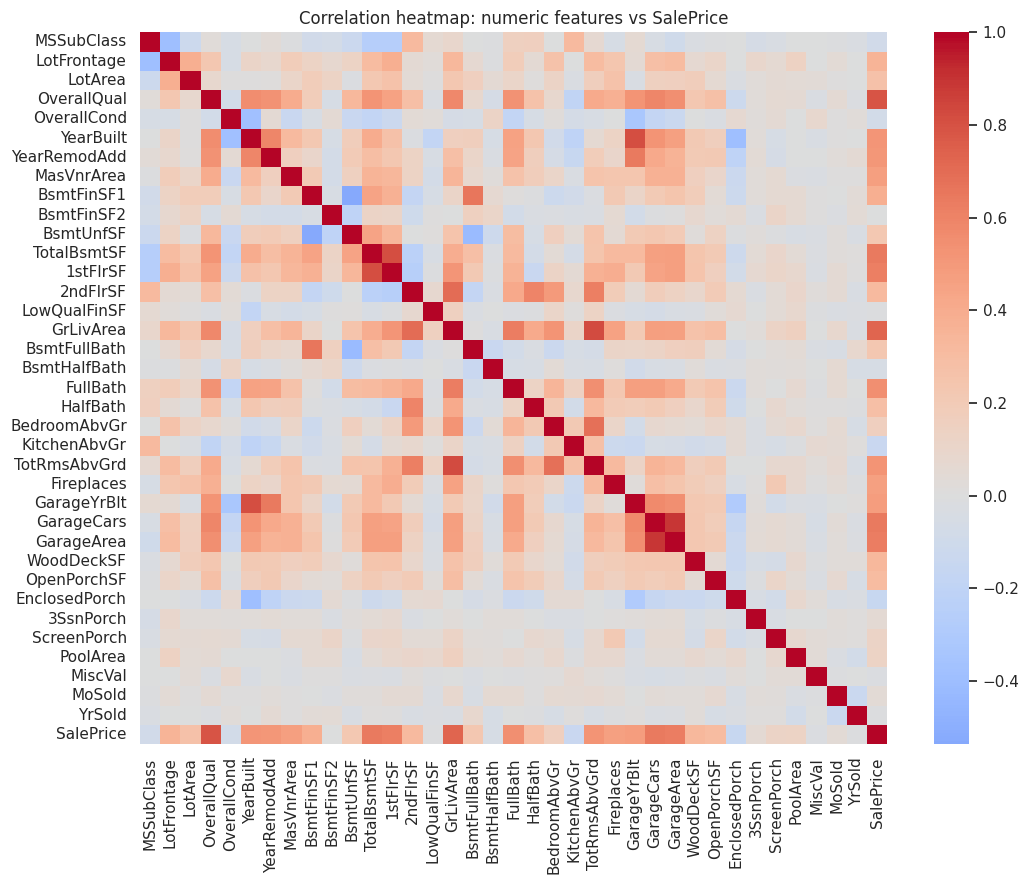

Top 10 numeric features most correlated with SalePrice:


OverallQual     0.791636
GrLivArea       0.728507
TotalBsmtSF     0.644249
GarageCars      0.641793
GarageArea      0.631588
1stFlrSF        0.619552
FullBath        0.554409
TotRmsAbvGrd    0.525357
YearBuilt       0.517393
YearRemodAdd    0.509378
Name: SalePrice, dtype: float64


Insight: OverallQual and GrLivArea are consistently the strongest numeric signals for price -- this cross-checks against the Random Forest importance chart later in this notebook and against the permutation importance computed downstream in Role D's notebook.


In [7]:
# --- Correlation heatmap & top correlates of SalePrice ---
corr = train_full_clean[numeric_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap: numeric features vs SalePrice")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_correlation_heatmap.png", dpi=150)
plt.show()

top_corr = corr["SalePrice"].drop("SalePrice").abs().sort_values(ascending=False).head(10)
print("Top 10 numeric features most correlated with SalePrice:")
display(top_corr)

top_corr.reset_index().rename(columns={"index": "Feature", "SalePrice": "Abs_Correlation"}).to_csv(
    RESULTS_DIR / "02_top_correlations.csv", index=False
)

print(
    "\nInsight: OverallQual and GrLivArea are consistently the strongest numeric signals for price -- "
    "this cross-checks against the Random Forest importance chart later in this notebook and against "
    "the permutation importance computed downstream in Role D's notebook."
)

In [8]:
# Finalize the EDA-cleaned training data used from this point forward
X_train_eda = train_full_clean.drop(columns=["SalePrice"])
y_train_eda = train_full_clean["SalePrice"]

pd.Series(removed_idx, name="removed_train_idx").to_csv(RESULTS_DIR / "02_removed_outlier_indices.csv", index=False)
print(f"Saved {len(removed_idx)} removed training index/indices to results/02_removed_outlier_indices.csv")
print("Roles C and D should apply the SAME removal to their copies of the training data for consistency.")

Saved 2 removed training index/indices to results/02_removed_outlier_indices.csv
Roles C and D should apply the SAME removal to their copies of the training data for consistency.


## 2.2 Tree Models: Decision Tree & Random Forest

**Bug Fix (Logged Decision):** The initial implementation of `prepare_tree_features` identified columns for ordinal encoding by matching substring patterns `"Qual"` or `"Cond"` directly in the **column names**. In the Ames Housing dataset, this logic unintentionally matched `Condition1`, `Condition2`, and `SaleCondition` - categorical features that do not use the standard `Ex/Gd/TA/Fa/Po` rating scale. Consequently, all entries in those three columns were mapped to `NaN` and subsequently filled with a constant `0`, effectively erasing three valid predictors from downstream models without raising runtime errors.

**Corrective Implementation:** The updated preprocessing logic checks column **data content** rather than naming patterns. A column is now converted via ordinal encoding only if all non-null values belong strictly to the target set `{Ex, Gd, TA, Fa, Po}`.

In [9]:
QUAL_VALUE_SET = {"Ex", "Gd", "TA", "Fa", "Po"}
QUAL_MAP = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1}

def prepare_tree_features(df_train, df_test):
    X_tr = df_train.copy()
    X_te = df_test.copy()

    # Identify categorical columns, robust across pandas versions (object or string dtype)
    candidate_cols = X_tr.select_dtypes(include=["object", "category"]).columns.tolist()
    if not candidate_cols:
        candidate_cols = [
            c for c in X_tr.columns
            if pd.api.types.is_object_dtype(X_tr[c]) or pd.api.types.is_string_dtype(X_tr[c])
        ]

    # Ordinal-encode ONLY columns whose values are genuinely Ex/Gd/TA/Fa/Po ratings.
    # This is a value-based check, not a name-based one -- see the fix note above.
    qual_cols = [c for c in candidate_cols if set(X_tr[c].dropna().unique()).issubset(QUAL_VALUE_SET)]
    for col in qual_cols:
        X_tr[col] = X_tr[col].map(QUAL_MAP)
        X_te[col] = X_te[col].map(QUAL_MAP)

    # Median imputation for numerical features (fit on TRAIN only)
    num_cols = X_tr.select_dtypes(include=["int64", "float64"]).columns.tolist()
    for col in num_cols:
        median_val = X_tr[col].median()
        X_tr[col] = X_tr[col].fillna(median_val)
        X_te[col] = X_te[col].fillna(median_val)

    # Mode imputation & One-Hot Encoding for remaining categorical features (fit on TRAIN only)
    cat_cols = [c for c in X_tr.columns if c not in num_cols]
    for col in cat_cols:
        mode_val = X_tr[col].mode()[0]
        X_tr[col] = X_tr[col].fillna(mode_val)
        X_te[col] = X_te[col].fillna(mode_val)

    X_tr = pd.get_dummies(X_tr, drop_first=True)
    X_te = pd.get_dummies(X_te, drop_first=True)
    X_tr, X_te = X_tr.align(X_te, join="left", axis=1, fill_value=0)

    return X_tr, X_te, qual_cols

X_train_proc, X_test_proc, qual_cols_used = prepare_tree_features(X_train_eda, X_test)
print(f"Ordinal-encoded quality columns (matched by VALUE, not name): {qual_cols_used}")
print(f"Processed feature matrix shape: {X_train_proc.shape}")

Ordinal-encoded quality columns (matched by VALUE, not name): ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
Processed feature matrix shape: (1166, 217)


In [10]:
dt_model = DecisionTreeRegressor(random_state=RANDOM_SEED, max_depth=8, min_samples_leaf=5)
dt_model.fit(X_train_proc, y_train_eda)
y_pred_dt = dt_model.predict(X_test_proc)

dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("--- Decision Tree Results ---")
print(f"MAE:  ${dt_mae:,.2f}\nRMSE: ${dt_rmse:,.2f}\nR2:   {dt_r2:.4f}")
print("Note: max_depth=8, min_samples_leaf=5 constrains overfitting vs. an unbounded tree.")

--- Decision Tree Results ---
MAE:  $25,664.14
RMSE: $38,598.27
R2:   0.8058
Note: max_depth=8, min_samples_leaf=5 constrains overfitting vs. an unbounded tree.


In [11]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1)
rf_model.fit(X_train_proc, y_train_eda)
y_pred_rf = rf_model.predict(X_test_proc)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("--- Random Forest Results ---")
print(f"MAE:  ${rf_mae:,.2f}\nRMSE: ${rf_rmse:,.2f}\nR2:   {rf_r2:.4f}")

--- Random Forest Results ---
MAE:  $17,329.53
RMSE: $28,037.01
R2:   0.8975


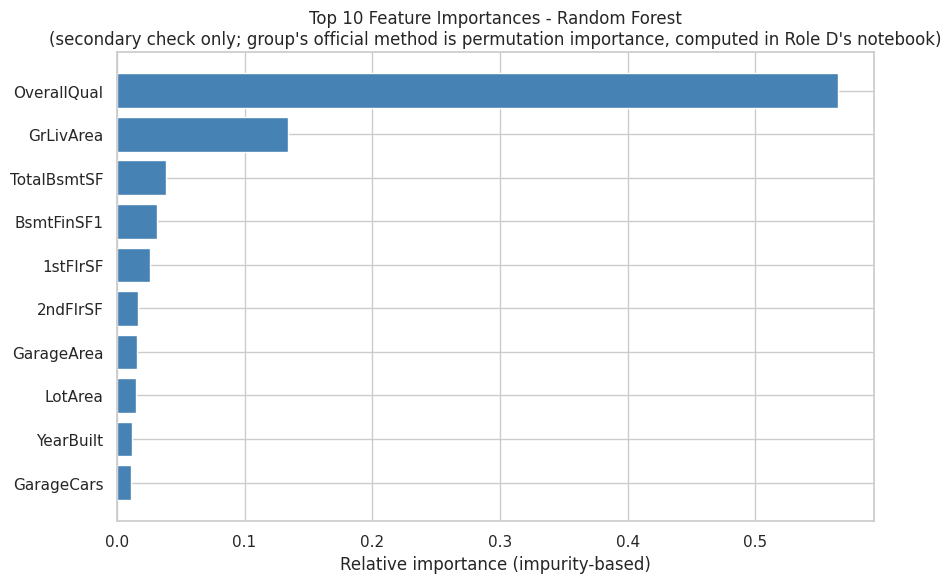

In [12]:
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[-10:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(range(len(top_idx)), importances[top_idx], color="steelblue")
ax.set_yticks(range(len(top_idx)))
ax.set_yticklabels([X_train_proc.columns[i] for i in top_idx])
ax.set_xlabel("Relative importance (impurity-based)")
ax.set_title("Top 10 Feature Importances - Random Forest\n(secondary check only; group's official method is permutation importance, computed in Role D's notebook)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "02_rf_feature_importance.png", dpi=150)
plt.show()

In [13]:
tree_metrics = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "MAE": [dt_mae, rf_mae],
    "RMSE": [dt_rmse, rf_rmse],
    "R2 Score": [dt_r2, rf_r2],
})
tree_metrics.to_csv(RESULTS_DIR / "02_tree_metrics.csv", index=False)

X_train_proc.to_csv(RESULTS_DIR / "X_train_processed.csv", index=False)
X_test_proc.to_csv(RESULTS_DIR / "X_test_processed.csv", index=False)
y_train_eda.to_csv(RESULTS_DIR / "y_train.csv", index=False)
y_test.to_csv(RESULTS_DIR / "y_test.csv", index=False)

print("Artifacts saved to results/:")
print("- 02_tree_metrics.csv")
print("- 02_missingness_meaning.csv, 02_missingness_other.csv")
print("- 02_grlivarea_outliers.png, 02_removed_outlier_indices.csv")
print("- 02_skewness.csv, 02_correlation_heatmap.png, 02_top_correlations.csv")
print("- 02_rf_feature_importance.png")
print("- X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv")

Artifacts saved to results/:
- 02_tree_metrics.csv
- 02_missingness_meaning.csv, 02_missingness_other.csv
- 02_grlivarea_outliers.png, 02_removed_outlier_indices.csv
- 02_skewness.csv, 02_correlation_heatmap.png, 02_top_correlations.csv
- 02_rf_feature_importance.png
- X_train_processed.csv, X_test_processed.csv, y_train.csv, y_test.csv


## 2.3 EDA Insight Log

| # | Finding | Decision / Action |
|---|---|---|
| 1 | 1 exact duplicate row present in training data | Dropped strictly from the training set |
| 2 | ~15 columns use `NA` to denote structural absence (e.g., `PoolQC`, `BsmtQual`) | Preserved structural NAs; encoded `NA` as its own distinct category or 0 on ordinal scales |
| 3 | 2 training rows show extreme `GrLivArea` alongside disproportionately low `SalePrice` (known Ames anomaly) | Removed from the training set only; test set left completely untouched |
| 4 | `SalePrice` and several numeric features exhibit right-skewness | Logged finding; $log(1+p)$ target transformation maintained as the agreed fallback if linear model residuals show heteroscedasticity |
| 5 | `OverallQual` and `GrLivArea` show the highest linear correlation with `SalePrice` | Cross-validated against Random Forest feature importance and downstream permutation importance analyses |
| 6 | Initial `prepare_tree_features` method contained a silent string-matching bug on column names (`"Qual"/"Cond"`), corrupting `Condition1`, `Condition2`, and `SaleCondition` into zero-variance columns | Updated logic to match columns by actual unique values (only columns where non-null entries form a subset of `{Ex, Gd, TA, Fa, Po}`) |

---

### Downstream Handoff
Subsequent notebooks must read `results/02_removed_outlier_indices.csv` to apply identical training-row filtering prior to building the shared leakage-safe pipeline, ensuring all project models train on the identical cleaned split.